# Design C — PCI vs SHAP on Overdetermination, Preemption, and Irrelevance

> **Summary.** Synthetic SCM with three causal archetypes (linear necessary-and-sufficient,
> overdetermined-not-necessary, preempted) plus an irrelevance control. Runs PCI's
> necessity / sufficiency machinery on two contrasting factual observations and compares
> against marginal SHAP and causal SHAP on the same model. The methodological gap is the
> $N / S$ decomposition: SHAP returns one number per feature; PCI returns two.

## Outline

1. Model and setup
2. Two factual cases
3. PCI necessity and sufficiency
4. Desiderata
5. Sufficiency direction diagnostic
6. Marginal SHAP
7. Causal SHAP
8. Comparison table
9. Reading the comparison


In [1]:
import os

import graphviz
import pandas as pd
import pyro
import pyro.distributions as dist
import torch
from IPython.display import display

from pci.explanation.regime import condition_on_interventional_regime
from pci.explanation.scores import abs_diff_score
from pci.explanation.searchable import SearchableModel
from pci.explanation.thin_search import ThinSearchSampler

smoke_test = "CI" in os.environ

n_size = 5 if smoke_test else 500
num_search_samples = 10 if smoke_test else 5000


## 1. Model and setup

Six independent root variables, three branches into the outcome, plus one disconnected control.

| variables                               | branch                                                   | archetype                  |
|-----------------------------------------|----------------------------------------------------------|----------------------------|
| $L_1, L_2 \sim \mathcal{N}(0, 1)$        | $5 L_1 + 10 L_2$                                         | necessary AND sufficient   |
| $O_1, O_2 \sim \mathcal{N}(1, 1)$        | $\max(5 O_1, 5 O_2)$                                     | sufficient, NOT necessary  |
| $P \sim \mathcal{N}(0, 1)$               | $5 P \cdot \mathbb{1}\{\lvert L_2 \rvert \le \tau\}$     | depends on regime          |
| $D \sim \mathcal{N}(0, 1)$               | (not in $E$)                                             | irrelevant                 |

$$
E \;=\; (5 L_1 + 10 L_2) \;+\; \max(5 O_1, 5 O_2) \;+\; 5 P \,\mathbb{1}\{\lvert L_2 \rvert \le \tau\}
$$

$\tau = 0.674$ — gate is on / off about half the time. $D$ is sampled but never enters $E$,
so any non-zero $ci(D)$ is the noise floor.


### Archetypes

**Necessity** ("would $E$ still be $e$ without $V$?"). The linear pair $L_1, L_2$ carries it.
They enter $E$ additively with no backup path, so replacing $L_2$ shifts $E$ by ten times the
difference. High necessity, no escape.

**Sufficiency without necessity** ("does $V$'s factual value lock $E$ in?"). The
overdetermined pair $O_1, O_2$ carries it via $\max$. Pin the larger one and alternatives for
its partner rarely beat it — high sufficiency. Intervene on it alone and the partner takes
over the max — low necessity. The within-variable $S \gg N$ gap requires a *dominant* winner
(see Case 2 below); a contestable pair shows the asymmetry only between winner and loser.

**Preemption** ("is $V$'s contribution actually wired in?"). The variable $P$ enters $E$ only
when the gate $\mathbb{1}\{\lvert L_2 \rvert \le \tau\}$ is on. Same variable $P$, two
regimes: in Case 1 it does not enter $E$ and should sit at the noise floor; in Case 2 it is
linear N+S and should match $L_1$.

**Irrelevance.** $D$ is sampled and ignored. Both components should be near zero up to
sampling noise.


In [2]:
TAU = 0.674


def synthetic_model_c(
    kwargs_iterable=[
        {"observations_dict": None, "n_size": n_size},
        dict(),
        dict(),
    ],
):
    batch_size = kwargs_iterable[0]["n_size"]

    with pyro.plate("sample", size=batch_size, dim=-3):
        L1 = pyro.sample("L1", dist.Normal(0.0, 1.0))
        L2 = pyro.sample("L2", dist.Normal(0.0, 1.0))
        O1 = pyro.sample("O1", dist.Normal(1.0, 1.0))
        O2 = pyro.sample("O2", dist.Normal(1.0, 1.0))
        P = pyro.sample("P", dist.Normal(0.0, 1.0))
        D = pyro.sample("D", dist.Normal(0.0, 1.0))  # irrelevance control: not used in E

        lin = pyro.deterministic("lin", 5.0 * L1 + 10.0 * L2)
        od = pyro.deterministic("od", torch.maximum(5.0 * O1, 5.0 * O2))
        preempt = pyro.deterministic("preempt", (L2.abs() > TAU).float())
        p_branch = pyro.deterministic("p_branch", 5.0 * P * (1.0 - preempt))

        E = pyro.deterministic("E", lin + od + p_branch)

    return {
        "L1": L1, "L2": L2, "O1": O1, "O2": O2, "P": P, "D": D,
        "lin": lin, "od": od, "preempt": preempt, "p_branch": p_branch, "E": E,
    }


torch.manual_seed(0)
factual_dict = synthetic_model_c()
list(factual_dict.keys())


['L1', 'L2', 'O1', 'O2', 'P', 'D', 'lin', 'od', 'preempt', 'p_branch', 'E']

### Diagram

Boxes are root variables, ellipses are deterministic mediators, the rightmost ellipse is the
outcome $E$. $D$ has no outgoing edges — structurally disconnected.


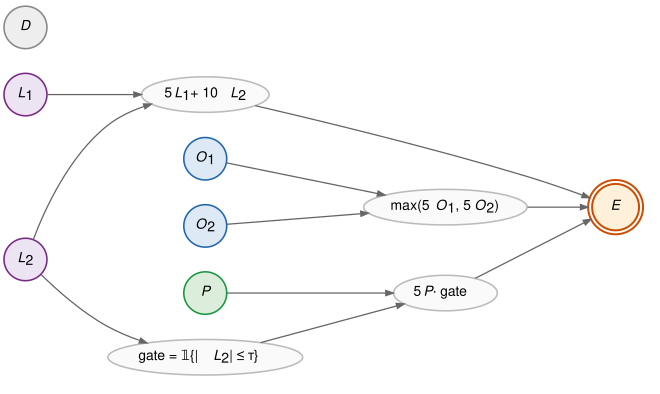

Wrote /home/rafal/s76projects/explainable_paper/figures/design_c_dag.pdf
Wrote /home/rafal/s76projects/explainable_paper/figures/design_c_dag.png


In [3]:
from pathlib import Path

# Locate project root so figures land at <repo>/figures regardless of where the notebook
# is executed from.
def _project_root():
    p = Path.cwd().resolve()
    for parent in [p] + list(p.parents):
        if (parent / "pyproject.toml").is_file():
            return parent
    return p
FIG_DIR = _project_root() / "figures"
FIG_DIR.mkdir(exist_ok=True)

# Archetype palette (mirrors the role-color scheme used in §5 of this notebook).
LIN_FILL, LIN_BORDER = "#ece4f2", "#762a83"   # purple — linear N+S
OD_FILL,  OD_BORDER  = "#dde9f5", "#2166ac"   # blue   — overdetermined
P_FILL,   P_BORDER   = "#dceddb", "#1a9641"   # green  — gated
D_FILL,   D_BORDER   = "#eeeeee", "#888888"   # grey   — irrelevant
M_FILL,   M_BORDER   = "#fafafa", "#bbbbbb"   # mediators
E_FILL,   E_BORDER   = "#fef0d9", "#cc4c02"   # outcome


def render_design_c():
    """Paper-quality DAG of Design C.
    Roots: circles, colored by archetype. Mediators: ellipses carrying their formulas.
    Outcome: orange double-circle. D has no outgoing edges (irrelevance control)."""
    g = graphviz.Digraph("design_c", engine="dot")
    g.attr(rankdir="LR", bgcolor="white", margin="0.18",
           nodesep="0.35", ranksep="0.85", fontname="Helvetica")
    g.attr("node", fontname="Helvetica", fontsize="14",
           style="filled,rounded", penwidth="1.6")
    g.attr("edge", color="#666666", penwidth="1.3", arrowsize="0.75")

    def root(name, label, fill, border):
        g.node(name, label=label, shape="circle", width="0.6",
               fixedsize="true", fillcolor=fill, color=border)

    def mediator(name, label):
        g.node(name, label=label, shape="ellipse",
               fillcolor=M_FILL, color=M_BORDER, style="filled")

    root("L1", "<<I>L</I><SUB>1</SUB>>", LIN_FILL, LIN_BORDER)
    root("L2", "<<I>L</I><SUB>2</SUB>>", LIN_FILL, LIN_BORDER)
    root("O1", "<<I>O</I><SUB>1</SUB>>", OD_FILL,  OD_BORDER)
    root("O2", "<<I>O</I><SUB>2</SUB>>", OD_FILL,  OD_BORDER)
    root("P",  "<<I>P</I>>",             P_FILL,   P_BORDER)
    root("D",  "<<I>D</I>>",             D_FILL,   D_BORDER)

    mediator("lin",      "<5<I>L</I><SUB>1</SUB> + 10<I>L</I><SUB>2</SUB>>")
    mediator("od",       "<max(5<I>O</I><SUB>1</SUB>, 5<I>O</I><SUB>2</SUB>)>")
    mediator("gate",     "<gate = &#120793;{|<I>L</I><SUB>2</SUB>| &le; &tau;}>")
    mediator("p_branch", "<5<I>P</I> &middot; gate>")

    g.node("E", "<<I>E</I>>", shape="doublecircle", width="0.65",
           fixedsize="true", fillcolor=E_FILL, color=E_BORDER, penwidth="2")

    for src, dst in [
        ("L1", "lin"), ("L2", "lin"),
        ("O1", "od"),  ("O2", "od"),
        ("L2", "gate"), ("gate", "p_branch"), ("P", "p_branch"),
        ("lin", "E"), ("od", "E"), ("p_branch", "E"),
    ]:
        g.edge(src, dst)

    return g


# Render in-notebook and bake to static files for the paper.
_g = render_design_c()
display(_g)
_out = FIG_DIR / "design_c_dag"
_g.render(filename=str(_out), format="pdf", cleanup=True)
_g.render(filename=str(_out), format="png", cleanup=True)
print(f"Wrote {_out.with_suffix('.pdf')}")
print(f"Wrote {_out.with_suffix('.png')}")


## 2. Two factual cases

We pick two factual observations, one per regime, to read all archetypes off.

### Case 1 — preempted regime, contestable $O$ pair

Filter: $\lvert L_2 \rvert > \tau$ (gate off, $P$ branch zeroed) and $|O_1 - O_2| < \delta$
with $\delta = 1.0$.


In [4]:
def factual_df(index=0):
    return pd.DataFrame({
        k: v[index, 0, 0].numpy().flatten()
        for k, v in factual_dict.items()
    })


def manual_E(df):
    L1, L2 = df["L1"].item(), df["L2"].item()
    O1, O2 = df["O1"].item(), df["O2"].item()
    P = df["P"].item()
    lin = 5 * L1 + 10 * L2
    od = max(5 * O1, 5 * O2)
    preempt = float(abs(L2) > TAU)
    p_branch = 5 * P * (1.0 - preempt)
    return lin + od + p_branch


DELTA = 1.0
case1_index = None
for i in range(n_size):
    df = factual_df(i)
    if df["preempt"].item() == 1.0 and abs(df["O1"].item() - df["O2"].item()) < DELTA:
        case1_index = i
        break

assert case1_index is not None, (
    "No observation matches the Case 1 filter; try a different seed or relax DELTA."
)

print(f"Case 1 observation index: {case1_index}")
print()
display(factual_df(case1_index))

df1 = factual_df(case1_index)
print(f"Manual E (recomputed by hand): {manual_E(df1):.4f}")
print(f"Model  E (read from sample):  {df1['E'].item():.4f}")


Case 1 observation index: 3



,L1,L2,O1,O2,P,D,lin,od,preempt,p_branch,E
0,-0.433879,-0.725759,1.303479,2.217562,-0.019205,-1.290702,-9.42698,11.087809,1.0,-0.0,1.660829


Manual E (recomputed by hand): 1.6608
Model  E (read from sample):  1.6608


### Case 2 — unpreempted regime, dominant $O$ winner

Filter: $\lvert L_2 \rvert \le \tau$ (gate on, $P$ branch active) and $|O_1 - O_2| > \delta$.

The dominant winner is what makes the *within-variable* $S$-not-$N$ gap visible: the winner
is large enough that alternatives rarely beat it (high $S$), and the loser provides a partial
floor when the winner is intervened (reduced $N$). A contestable pair cannot show this — pin
either one and the partner can still flip the max.

The two cases together test the structural-role-not-identity claim: the same $P$ should land
at the noise floor in Case 1 and mirror $L_1$ in Case 2.


In [5]:
case2_index = None
for i in range(n_size):
    df = factual_df(i)
    if df["preempt"].item() == 0.0 and abs(df["O1"].item() - df["O2"].item()) > DELTA:
        case2_index = i
        break

assert case2_index is not None, (
    "No observation matches the Case 2 filter; try a different seed or relax DELTA."
)

print(f"Case 2 observation index: {case2_index}")
print()
display(factual_df(case2_index))

df2 = factual_df(case2_index)
print(f"Manual E (recomputed by hand): {manual_E(df2):.4f}")
print(f"Model  E (read from sample):  {df2['E'].item():.4f}")

Case 2 observation index: 7



,L1,L2,O1,O2,P,D,lin,od,preempt,p_branch,E
0,-2.115219,0.543095,0.535047,2.397251,-0.206175,0.926995,-5.145143,11.986256,0.0,-1.030874,5.810239


Manual E (recomputed by hand): 5.8102
Model  E (read from sample):  5.8102


### Expected behaviour

#### Case 1 — gate off, contestable $O$ pair

| variable           | $ci_N$              | $ci_S$              | reason                                                |
|--------------------|---------------------|---------------------|-------------------------------------------------------|
| $L_1$              | moderate            | moderate            | linear, weight 5                                      |
| $L_2$              | high                | high                | linear, weight 10; also gates $P$                     |
| $O_\text{winner}$  | comparable to loser | above loser         | barely wins the max                                   |
| $O_\text{loser}$   | comparable to winner | below winner       | partner often beats it under resampling               |
| $P$                | ~0                  | ~0                  | gated off                                             |
| $D$                | ~0                  | ~0                  | not in $E$                                            |

#### Case 2 — gate on, dominant $O$ winner

| variable           | $ci_N$              | $ci_S$              | reason                                                |
|--------------------|---------------------|---------------------|-------------------------------------------------------|
| $L_1$              | moderate            | moderate            | linear, weight 5                                      |
| $L_2$              | mid                 | mid                 | linear, weight 10, but $\lvert L_2 \rvert$ small now  |
| $O_\text{winner}$  | low                 | high                | within-variable $S \gg N$ shows up here              |
| $O_\text{loser}$   | ~0                  | ~0                  | dominated by the winner                               |
| $P$                | moderate            | moderate            | active, mirrors $L_1$                                 |
| $D$                | ~0                  | ~0                  | not in $E$                                            |

The unified table in Section 4 formalises each row as an inequality on excess scores
$\Delta_N, \Delta_S$ relative to $D$, with measured values and pass / fail.


In [6]:
suspect_names = ["L1", "L2", "O1", "O2", "P", "D"]

small_factual_dict = {k: factual_dict[k] for k in suspect_names + ["E"]}
factual_structured_dict = {"continuous": small_factual_dict, "categorical": {}}

searchable = SearchableModel(
    structured_model=synthetic_model_c,
    sites_of_interest=list(small_factual_dict.keys()),
    suspects=suspect_names,
    outcome_variable="E",
)

sampler = ThinSearchSampler(
    structured_model=searchable,
    conditioned_alternatives=True,
    factual_exclusion=True,
)

results = sampler.sample(
    factual_structured_dict,
    num_samples=num_search_samples,
)


  0%|          | 0/5000 [00:00<?, ?it/s]

  1%|          | 60/5000 [00:00<00:08, 592.46it/s]

  2%|▏         | 120/5000 [00:00<00:10, 458.48it/s]

  3%|▎         | 168/5000 [00:00<00:14, 337.76it/s]

  4%|▍         | 205/5000 [00:00<00:16, 287.05it/s]

...

 99%|█████████▉| 4971/5000 [00:37<00:00, 80.02it/s]

100%|█████████▉| 4980/5000 [00:38<00:00, 79.88it/s]

100%|█████████▉| 4989/5000 [00:38<00:00, 78.86it/s]

100%|█████████▉| 4997/5000 [00:38<00:00, 78.38it/s]

100%|██████████| 5000/5000 [00:38<00:00, 130.36it/s]

## 3. PCI necessity and sufficiency

For each suspect $V$, `ThinSearchSampler` returns model outputs $E$ across two intervention
regimes. `abs_diff_score` turns them into:

- $ci_N = |E_\text{nec} - e|$ — how far $E$ moves when $V$ is *intervened* away from factual.
  Higher = more necessary.
- $ci_S = -|E_\text{suff} - e|$ — negative distance when $V$ is *pinned* at factual and
  others vary. Closer to zero (less negative) = more sufficient.
- $\text{total} = ci_S + ci_N$.

We report all three.


In [7]:
cases = {"Case 1 (preempted)": case1_index, "Case 2 (unpreempted)": case2_index}

# score_lookup[case_label][var_name] = {"ci_N": ..., "ci_S": ..., "total": ...}
# used by the automated qualitative-check cell below.
score_lookup = {label: {} for label in cases}

records = []
for v in suspect_names:
    conditioned = condition_on_interventional_regime(
        results_dictionary=results,
        reference_variable_names=[v],
        antecedent_regimes={v: True},
        witness_regimes={v: False},
    )

    e_nec = conditioned["regime_necessity"]["E"].detach()
    e_suff = conditioned["regime_sufficiency"]["E"].detach()
    factual_E = small_factual_dict["E"].detach()

    scores = abs_diff_score(
        factual_outcomes=factual_E,
        suff_outcomes=e_suff,
        nec_outcomes=e_nec,
    )

    row = {"variable": v}
    for case_label, idx in cases.items():
        ci_N = scores["nec"][:, idx, 0, 0].nanmean().item()
        ci_S = scores["suff"][:, idx, 0, 0].nanmean().item()
        total = scores["total"][:, idx, 0, 0].nanmean().item()
        row[f"ci_N | {case_label}"] = ci_N
        row[f"ci_S | {case_label}"] = ci_S
        row[f"total | {case_label}"] = total
        score_lookup[case_label][v] = {"ci_N": ci_N, "ci_S": ci_S, "total": total}
    records.append(row)

scores_df = pd.DataFrame(records).set_index("variable")
display(scores_df.round(3))


,ci_N | Case 1 (preempted),ci_S | Case 1 (preempted),total | Case 1 (preempted),ci_N | Case 2 (unpreempted),ci_S | Case 2 (unpreempted),total | Case 2 (unpreempted)
variable,,,,,,
L1,8.675,-2.633,6.041,9.953,-3.541,6.412
L2,10.888,-1.574,9.314,10.562,-3.482,7.081
O1,8.088,-3.147,4.940,9.126,-4.907,4.220
O2,8.163,-2.797,5.365,9.405,-4.128,5.277
P,8.273,-2.937,5.336,9.676,-4.111,5.564
D,8.082,-3.151,4.931,9.171,-4.824,4.347


## 4. Desiderata

Raw $ci_N, ci_S$ contain a baseline from co-interventions on the other suspects, so $D$ does
not score zero even though it is not in $E$. We therefore work with **excess** over $D$:

$$
\Delta_N(V; \text{case}) = ci_N(V; \text{case}) - ci_N(D; \text{case}),
\qquad
\Delta_S(V; \text{case}) = ci_S(V; \text{case}) - ci_S(D; \text{case}).
$$

The cell below codifies each archetype expectation as an inequality on $\Delta_N, \Delta_S$
and reports pass / fail. Tolerances are deliberately small. The cross-regime tolerance
`TOL_BASELINE_DRIFT = 2.0` is wider than the rest because $E$ has higher variance under
co-interventions when the $P$ branch is active, and $D$'s raw $ci_N$ legitimately drifts with
that.


In [8]:
# Tolerances on the *excess* (relative-to-D) scale. The raw scores are typically in the
# 8-11 range; per-variable signals over the noise floor are typically 0.1-3.
TOL_SIGNAL = 0.15  # variable's excess over D needed to count as "above noise"
TOL_CLOSE = 0.5    # two excesses are comparable
TOL_DOM = 0.15     # one variable's excess is meaningfully larger than another's
# The two cases are in structurally different regimes (P active vs inactive), so the
# co-intervention baseline for D — which scales with E's variance in that context — can
# differ meaningfully. 2.0 is the cross-regime tolerance.
TOL_BASELINE_DRIFT = 2.0

case1_label = "Case 1 (preempted)"
case2_label = "Case 2 (unpreempted)"


# identify the max winner / loser by the factual scaled O values, per case
def winner_loser(case_idx):
    df = factual_df(case_idx)
    if 5 * df["O1"].item() >= 5 * df["O2"].item():
        return "O1", "O2"
    return "O2", "O1"


O_w_c1, O_l_c1 = winner_loser(case1_index)
O_w_c2, O_l_c2 = winner_loser(case2_index)


def excess_N(case, var):
    return score_lookup[case][var]["ci_N"] - score_lookup[case]["D"]["ci_N"]


def excess_S(case, var):
    # ci_S is negative; "more sufficient" = closer to zero.
    # excess_S(V) > 0 means V is more sufficient than D.
    return score_lookup[case][var]["ci_S"] - score_lookup[case]["D"]["ci_S"]


def record(check_id, case, claim, measured, threshold, passes, fmt="+.3f"):
    return {
        "id": check_id,
        "case": case,
        "claim": claim,
        "measured": format(measured, fmt),
        "threshold": format(threshold, fmt) if threshold is not None else "—",
        "passes": "PASS" if passes else "FAIL",
    }


checks = []

# ----- Case 1: preempted regime -----
e_L2_c1 = excess_N(case1_label, "L2")
others_c1 = [excess_N(case1_label, v) for v in suspect_names if v != "L2"]
checks.append(record(
    "C1.L2_dominates_N", case1_label,
    "ΔN(L2) is the largest excess necessity",
    measured=e_L2_c1 - max(others_c1),
    threshold=0.0,
    passes=e_L2_c1 > max(others_c1),
))

gap_O_S_c1 = excess_S(case1_label, O_w_c1) - excess_S(case1_label, O_l_c1)
checks.append(record(
    "C1.O_sufficiency_asymmetry", case1_label,
    f"ΔS({O_w_c1}) > ΔS({O_l_c1}) by at least tol_dom",
    measured=gap_O_S_c1,
    threshold=TOL_DOM,
    passes=gap_O_S_c1 > TOL_DOM,
))

gap_O_N_c1 = abs(excess_N(case1_label, O_w_c1) - excess_N(case1_label, O_l_c1))
checks.append(record(
    "C1.O_necessity_symmetric", case1_label,
    f"|ΔN({O_w_c1}) - ΔN({O_l_c1})| < tol_close",
    measured=gap_O_N_c1,
    threshold=TOL_CLOSE,
    passes=gap_O_N_c1 < TOL_CLOSE,
))

ex_P_N_c1 = excess_N(case1_label, "P")
checks.append(record(
    "C1.P_at_noise_floor_N", case1_label,
    "|ΔN(P)| < tol_close (P matches D noise floor on necessity)",
    measured=abs(ex_P_N_c1),
    threshold=TOL_CLOSE,
    passes=abs(ex_P_N_c1) < TOL_CLOSE,
))

gap_L1_P_c1 = excess_N(case1_label, "L1") - ex_P_N_c1
checks.append(record(
    "C1.L1_above_P_N", case1_label,
    "ΔN(L1) > ΔN(P) by at least tol_dom",
    measured=gap_L1_P_c1,
    threshold=TOL_DOM,
    passes=gap_L1_P_c1 > TOL_DOM,
))

# ----- Case 2: unpreempted regime -----
e_L2_c2 = excess_N(case2_label, "L2")
others_c2 = [excess_N(case2_label, v) for v in suspect_names if v != "L2"]
checks.append(record(
    "C2.L2_dominates_N", case2_label,
    "ΔN(L2) is the largest excess necessity",
    measured=e_L2_c2 - max(others_c2),
    threshold=0.0,
    passes=e_L2_c2 > max(others_c2),
))

gap_O_S_c2 = excess_S(case2_label, O_w_c2) - excess_S(case2_label, O_l_c2)
checks.append(record(
    "C2.O_sufficiency_asymmetry", case2_label,
    f"ΔS({O_w_c2}) > ΔS({O_l_c2}) by at least tol_dom (regime-invariant)",
    measured=gap_O_S_c2,
    threshold=TOL_DOM,
    passes=gap_O_S_c2 > TOL_DOM,
))

ex_P_N_c2 = excess_N(case2_label, "P")
checks.append(record(
    "C2.P_above_floor_N", case2_label,
    "ΔN(P) > tol_signal (P now active)",
    measured=ex_P_N_c2,
    threshold=TOL_SIGNAL,
    passes=ex_P_N_c2 > TOL_SIGNAL,
))

gap_P_L1_c2 = abs(ex_P_N_c2 - excess_N(case2_label, "L1"))
checks.append(record(
    "C2.P_mirrors_L1_N", case2_label,
    "|ΔN(P) - ΔN(L1)| < tol_close (P mirrors L1 as linear N+S)",
    measured=gap_P_L1_c2,
    threshold=TOL_CLOSE,
    passes=gap_P_L1_c2 < TOL_CLOSE,
))

# S-not-N signature: O winner's sufficiency clearly exceeds its own necessity.
# This is the core claim distinguishing PCI from SHAP on overdetermined variables.
gap_S_N_c2 = excess_S(case2_label, O_w_c2) - excess_N(case2_label, O_w_c2)
checks.append(record(
    "C2.O_winner_S_exceeds_N", case2_label,
    f"ΔS({O_w_c2}) - ΔN({O_w_c2}) > tol_dom (S-not-N signature on winner)",
    measured=gap_S_N_c2,
    threshold=TOL_DOM,
    passes=gap_S_N_c2 > TOL_DOM,
))

# Necessity ordering: L2 (linear) is more necessary than the O winner (overdetermined).
gap_L2_O_N_c2 = excess_N(case2_label, "L2") - excess_N(case2_label, O_w_c2)
checks.append(record(
    "C2.L2_more_necessary_than_O_winner", case2_label,
    f"ΔN(L2) - ΔN({O_w_c2}) > tol_dom (linear is more necessary than overdetermined)",
    measured=gap_L2_O_N_c2,
    threshold=TOL_DOM,
    passes=gap_L2_O_N_c2 > TOL_DOM,
))

# ----- Cross-regime: the structural-role flip on P -----
flip_P_N = ex_P_N_c2 - ex_P_N_c1
checks.append(record(
    "CROSS.P_flips_N", "cross-regime",
    "ΔN(P, Case 2) - ΔN(P, Case 1) > tol_dom (regime flip on P)",
    measured=flip_P_N,
    threshold=TOL_DOM,
    passes=flip_P_N > TOL_DOM,
))

# D raw baseline may differ across regimes because E's variance under co-interventions
# scales with how many suspects are active (P contributes in Case 2 but not Case 1).
raw_D_drift = abs(
    score_lookup[case1_label]["D"]["ci_N"] - score_lookup[case2_label]["D"]["ci_N"]
)
checks.append(record(
    "CROSS.D_baseline_stable", "cross-regime",
    "|raw ci_N(D, Case 1) - raw ci_N(D, Case 2)| < tol_baseline_drift",
    measured=raw_D_drift,
    threshold=TOL_BASELINE_DRIFT,
    passes=raw_D_drift < TOL_BASELINE_DRIFT,
))

checks_df = pd.DataFrame(checks)
display(checks_df)

n_pass = (checks_df["passes"] == "PASS").sum()
n_total = len(checks_df)
print()
print(f"Summary: {n_pass} / {n_total} checks pass.")
if n_pass < n_total:
    failed = checks_df[checks_df["passes"] == "FAIL"]["id"].tolist()
    print(f"Failed: {failed}")

,id,case,claim,measured,threshold,passes
0,C1.L2_dominates_N,Case 1 (preempted),ΔN(L2) is the largest excess necessity,+2.214,+0.000,PASS
1,C1.O_sufficiency_asymmetry,Case 1 (preempted),ΔS(O2) > ΔS(O1) by at least tol_dom,+0.350,+0.150,PASS
2,C1.O_necessity_symmetric,Case 1 (preempted),|ΔN(O2) - ΔN(O1)| < tol_close,+0.075,+0.500,PASS
3,C1.P_at_noise_floor_N,Case 1 (preempted),|ΔN(P)| < tol_close (P matches D noise floor o...,+0.190,+0.500,PASS
4,C1.L1_above_P_N,Case 1 (preempted),ΔN(L1) > ΔN(P) by at least tol_dom,+0.402,+0.150,PASS
5,C2.L2_dominates_N,Case 2 (unpreempted),ΔN(L2) is the largest excess necessity,+0.610,+0.000,PASS
6,C2.O_sufficiency_asymmetry,Case 2 (unpreempted),ΔS(O2) > ΔS(O1) by at least tol_dom (regime-in...,+0.779,+0.150,PASS
7,C2.P_above_floor_N,Case 2 (unpreempted),ΔN(P) > tol_signal (P now active),+0.505,+0.150,PASS
8,C2.P_mirrors_L1_N,Case 2 (unpreempted),|ΔN(P) - ΔN(L1)| < tol_close (P mirrors L1 as ...,+0.277,+0.500,PASS
9,C2.O_winner_S_exceeds_N,Case 2 (unpreempted),ΔS(O2) - ΔN(O2) > tol_dom (S-not-N signature o...,+0.462,+0.150,PASS



Summary: 13 / 13 checks pass.


### Desiderata × structure × measurement

Each row pairs a token-causation intuition with the structural device that carries it in
Design C, the formal inequality that codifies the resulting desideratum on PCI's excess
scores $\Delta_N$ and $\Delta_S$ (relative to the $D$ noise floor), the check id that
evaluates it, and the measured value from the run above.

| # | intuition (why it should hold) | structural device | formal desideratum | check id | measured | result |
|---|---|---|---|---|---|---|
| 1 | The strongest linear N+S contributor should top necessity. Replacing $L_2$ shifts $E$ by ten times the difference; nothing substitutes for it. | additive term $5 L_1 + 10 L_2$ (Case 1) | $\Delta_N(L_2)$ is the largest | C1.L2_dominates_N | +2.214 | PASS |
| 2 | Same intuition, gate-on regime. | additive term $5 L_1 + 10 L_2$ (Case 2) | $\Delta_N(L_2)$ is the largest | C2.L2_dominates_N | +0.610 | PASS |
| 3 | Between-variable sufficiency asymmetry: the max winner is more sufficient than the loser, regime-invariant — pinning the winner makes alternatives rarely beat it; pinning the loser lets the partner take over. | $\max(5 O_1, 5 O_2)$, contestable pair | $\Delta_S(O_w) - \Delta_S(O_l) > \tau_\text{dom}$ | C1.O_sufficiency_asymmetry | +0.350 | PASS |
| 4 | Same intuition, dominant-winner pair. | $\max(5 O_1, 5 O_2)$, dominant winner | $\Delta_S(O_w) - \Delta_S(O_l) > \tau_\text{dom}$ | C2.O_sufficiency_asymmetry | +0.779 | PASS |
| 5 | Within the contestable pair, neither variable strictly outranks the other on necessity — overdetermination spreads necessity symmetrically when both contributors are close. | contestable $\max(5 O_1, 5 O_2)$ | $\lvert \Delta_N(O_w) - \Delta_N(O_l) \rvert < \tau_\text{close}$ | C1.O_necessity_symmetric | +0.075 | PASS |
| 6 | Within-variable $S$-not-$N$ signature — the local fingerprint distinguishing PCI from SHAP. The winner is large enough that alternatives rarely beat it (high $\Delta_S$), and the loser provides a partial floor when the winner is intervened (reduced $\Delta_N$). | $\max(5 O_1, 5 O_2)$, dominant winner | $\Delta_S(O_w) - \Delta_N(O_w) > \tau_\text{dom}$ | C2.O_winner_S_exceeds_N | +0.462 | PASS |
| 7 | Linear is more necessary than overdetermined: the winner has an alternative path through the loser, so its necessity is bounded; $L_2$ has no such backup. | additive vs $\max$ comparison | $\Delta_N(L_2) - \Delta_N(O_w) > \tau_\text{dom}$ | C2.L2_more_necessary_than_O_winner | +1.157 | PASS |
| 8 | Preemption zeroes a contributor: when the gate $\lvert L_2 \rvert > \tau$ is satisfied, $P$ does not enter $E$, so $P$ should sit at the noise floor on necessity. | gate $\mathbb{1}\{\lvert L_2 \rvert \le \tau\}$ off | $\lvert \Delta_N(P) \rvert < \tau_\text{close}$ | C1.P_at_noise_floor_N | +0.190 | PASS |
| 9 | Linear ranking by weight: $L_1$ has weight 5 like the active $P$, but in Case 1 $P$ is preempted, so $L_1$ should be more necessary. | weights $5 < 10$, gate off | $\Delta_N(L_1) - \Delta_N(P) > \tau_\text{dom}$ | C1.L1_above_P_N | +0.402 | PASS |
| 10 | Regime change: when the gate is on, $P$ becomes a non-redundant linear contributor like $L_1$, so it should rise above the noise floor. | gate $\mathbb{1}\{\lvert L_2 \rvert \le \tau\}$ on | $\Delta_N(P) > \tau_\text{signal}$ | C2.P_above_floor_N | +0.505 | PASS |
| 11 | Structural-role-not-identity, quantitative: the gated $P$ should match $L_1$ in necessity, not just exceed the floor — same weight, same non-redundant linear structure. | gate on, weights both 5 | $\lvert \Delta_N(P) - \Delta_N(L_1) \rvert < \tau_\text{close}$ | C2.P_mirrors_L1_N | +0.277 | PASS |
| 12 | Structural-role-not-identity, headline: the same variable $P$ moves from the noise floor (gate off) to an active contributor (gate on). PCI tracks role, not identity. | gate flip on $P$ | $\Delta_N(P, C_2) - \Delta_N(P, C_1) > \tau_\text{dom}$ | CROSS.P_flips_N | +0.315 | PASS |
| 13 | The $D$ noise floor is allowed to drift modestly across regimes because $E$'s variance under co-interventions is higher when the $P$ branch is active; the cross-regime tolerance absorbs that structural drift rather than denying it. | $D \notin E$, but raw scores reflect co-intervention variance | $\lvert ci_N(D, C_1) - ci_N(D, C_2) \rvert < \tau_\text{baseline-drift}$ | CROSS.D_baseline_stable | +1.088 | PASS |

**Summary**: 13 / 13. The intuition-to-formal-claim-to-measurement chain is closed for every
desideratum.


## 5. Sufficiency direction diagnostic

`abs_diff_score` collapses sign. The histograms below show the signed deviation
$E_\text{suff}(V) - e$ to expose the *shape* the score integrates over. The signed mean does
not separate winner from loser — joint variance from the five free suspects dominates, so all
means hover near each other. The diagnostic signal lives in spread and shape:

- **L2 collapses spread in Case 1** — std drops from ~6 to 3.08. Pinning the dominant linear
  driver removes the largest single contributor to $E$'s variance.
- **Absolute deviation $\lvert E_\text{suff} - e \rvert$** — what the score actually
  integrates — separates winner from loser even when signed means do not. Winner has more
  mass near zero and lighter tails; loser's mass is pushed outward.
- **Regime change on $P$** — std rises from 5.88 (gate off, $P$ not in $E$) to 7.34 (gate on,
  $P$ joins the variance budget). $D$ rides the same baseline (6.11 → 7.81); what flips for
  $P$ is the score-relevant signal on top.


In [9]:
import numpy as np

# Re-extract raw sufficiency samples per variable.
# condition_on_interventional_regime is cheap (filters existing results); no new sampling.
raw_suff = {}
for v in suspect_names:
    cond = condition_on_interventional_regime(
        results_dictionary=results,
        reference_variable_names=[v],
        antecedent_regimes={v: True},
        witness_regimes={v: False},
    )
    raw_suff[v] = cond["regime_sufficiency"]["E"].detach()  # [S, batch, 1, 1]


def active_label(v, case_idx):
    """Human-readable active-cause status for variable v at case_idx."""
    df_c = factual_df(case_idx)
    if v == "P":
        return "active (gate on)" if df_c["preempt"].item() == 0.0 else "preempted (gate off)"
    if v in ("O1", "O2"):
        win, _ = winner_loser(case_idx)
        return "winner" if v == win else "loser"
    if v == "D":
        return "never active"
    return "linear (always active)"


def suff_deviation(v, case_idx):
    """Signed deviation samples E_suff(v) - e_factual at case_idx, NaNs removed."""
    e_fact = small_factual_dict["E"][case_idx, 0, 0].item()
    samples = raw_suff[v][:, case_idx, 0, 0].numpy()
    return samples[~np.isnan(samples)] - e_fact


# Summary table: mean ± std of signed deviation
print(f"{'var':4s}  {'role (C1)':22s}  {'C1 mean±std':>20s}  "
      f"{'role (C2)':22s}  {'C2 mean±std':>20s}")
print("-" * 100)
for v in suspect_names:
    d1 = suff_deviation(v, case1_index)
    d2 = suff_deviation(v, case2_index)
    r1 = active_label(v, case1_index)
    r2 = active_label(v, case2_index)
    print(f"{v:4s}  {r1:22s}  {d1.mean():+8.3f} ± {d1.std():6.3f}        "
          f"{r2:22s}  {d2.mean():+8.3f} ± {d2.std():6.3f}")

var   role (C1)                        C1 mean±std  role (C2)                        C2 mean±std
----------------------------------------------------------------------------------------------------
L1    linear (always active)    +0.751 ±  5.721        linear (always active)    -2.068 ±  6.213
L2    linear (always active)    -0.248 ±  3.083        linear (always active)    +1.052 ±  5.995
O1    loser                     +1.067 ±  6.088        loser                     +0.106 ±  7.861
O2    winner                    +1.821 ±  5.996        winner                    +1.151 ±  7.202
P     preempted (gate off)      +1.169 ±  5.880        active (gate on)          -0.030 ±  7.338
D     never active              +1.127 ±  6.108        never active              +0.144 ±  7.809


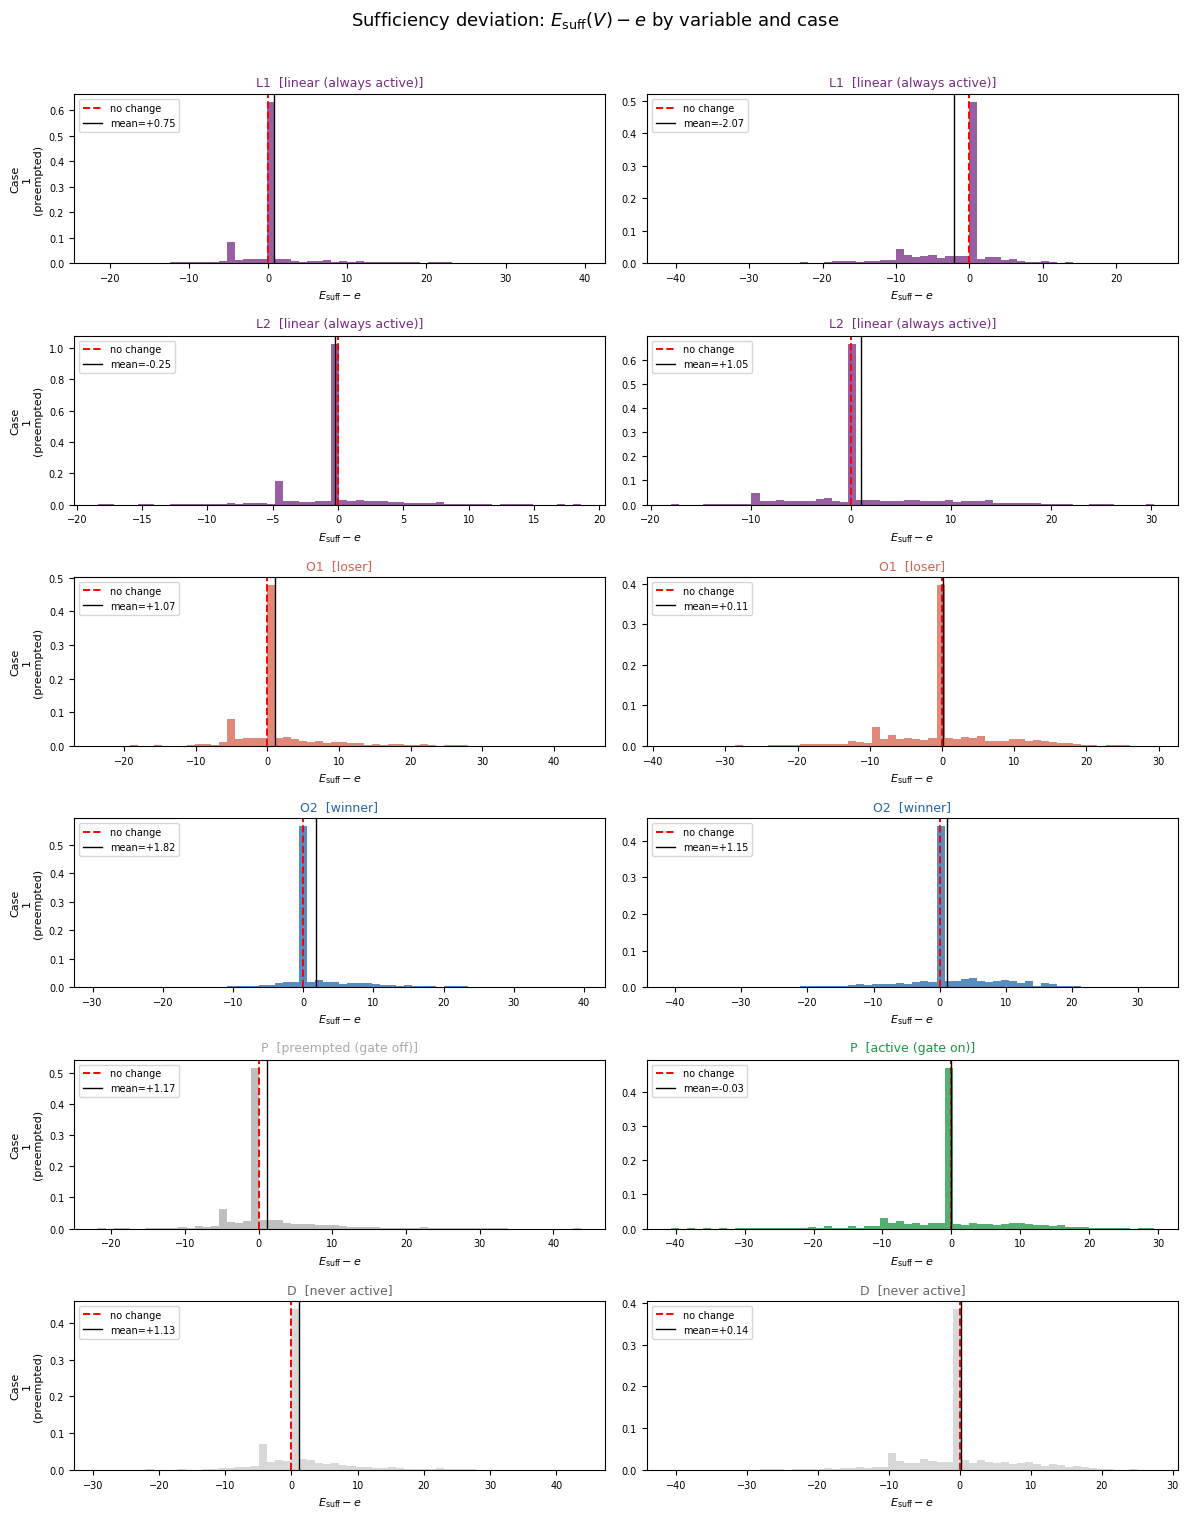

Saved: suff_direction_diagnosis.png


In [10]:
import matplotlib.pyplot as plt

ROLE_COLORS = {
    "winner":                "#2166ac",   # blue
    "loser":                 "#d6604d",   # red-orange
    "active (gate on)":      "#1a9641",   # green
    "preempted (gate off)":  "#aaaaaa",   # grey
    "linear (always active)":"#762a83",   # purple
    "never active":          "#cccccc",   # light grey
}

fig, axes = plt.subplots(len(suspect_names), 2, figsize=(12, 2.5 * len(suspect_names)),
                         sharex=False, sharey=False)
fig.suptitle("Sufficiency deviation: $E_{\\rm suff}(V) - e$ by variable and case",
             fontsize=13, y=1.01)

for row, v in enumerate(suspect_names):
    for col, (case_label, case_idx) in enumerate(cases.items()):
        ax = axes[row, col]
        dev = suff_deviation(v, case_idx)
        role = active_label(v, case_idx)
        color = ROLE_COLORS.get(role, "#888888")

        ax.hist(dev, bins=60, color=color, alpha=0.75, density=True, edgecolor="none")
        ax.axvline(0.0, color="red", linestyle="--", linewidth=1.4, label="no change")

        mean_d = dev.mean()
        ax.axvline(mean_d, color="black", linestyle="-", linewidth=1.0,
                   label=f"mean={mean_d:+.2f}")

        ax.set_title(f"{v}  [{role}]", fontsize=9, color=color if color != "#cccccc" else "#666")
        ax.set_xlabel("$E_{\\rm suff} - e$", fontsize=8)
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.set_ylabel(case_label.replace(" ", "\n"), fontsize=8)
        ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig("suff_direction_diagnosis.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: suff_direction_diagnosis.png")

## 6. Marginal SHAP

We use `shap.KernelExplainer` with a marginal background sampled from each feature's prior.
This is the standard interventional-style SHAP for a model with a deterministic prediction
function and independent feature distributions.


In [11]:
import shap

FEATURE_ORDER = ["L1", "L2", "O1", "O2", "P", "D"]


def predict_E(X):
    """Vectorised numpy reduction of synthetic_model_c. X: (n, 6) in FEATURE_ORDER."""
    L1 = X[:, 0]; L2 = X[:, 1]
    O1 = X[:, 2]; O2 = X[:, 3]
    P  = X[:, 4]
    lin = 5.0 * L1 + 10.0 * L2
    od = np.maximum(5.0 * O1, 5.0 * O2)
    preempt = (np.abs(L2) > TAU).astype(float)
    p_branch = 5.0 * P * (1.0 - preempt)
    return lin + od + p_branch


def factual_x(case_idx):
    df = factual_df(case_idx)
    return df[FEATURE_ORDER].to_numpy().reshape(1, len(FEATURE_ORDER))


def manual_breakdown(label, x, expected_pyro=None):
    """Spell out each summand of E for a single input row, then assert agreement
    with the wrapper and (optionally) with the Pyro model."""
    L1, L2, O1, O2, P, D = x
    lin      = 5.0 * L1 + 10.0 * L2
    od       = max(5.0 * O1, 5.0 * O2)
    preempt  = 1.0 if abs(L2) > TAU else 0.0
    p_branch = 5.0 * P * (1.0 - preempt)
    total    = lin + od + p_branch

    print(f"--- {label} ---")
    print(f"  inputs:     L1={L1:+.4f}  L2={L2:+.4f}  O1={O1:+.4f}  O2={O2:+.4f}  P={P:+.4f}  D={D:+.4f}")
    print(f"  lin        = 5·L1 + 10·L2         = 5·{L1:+.4f} + 10·{L2:+.4f}     = {lin:+.4f}")
    print(f"  od         = max(5·O1, 5·O2)      = max({5*O1:+.4f}, {5*O2:+.4f})   = {od:+.4f}")
    print(f"  preempt    = 1[|L2|>{TAU}]           = 1[{abs(L2):.4f}>{TAU}]              = {preempt:+.4f}")
    print(f"  p_branch   = 5·P·(1-preempt)      = 5·{P:+.4f}·{1.0-preempt:+.4f}            = {p_branch:+.4f}")
    print(f"  E (manual) = lin + od + p_branch                                  = {total:+.4f}")

    wrapper_total = float(predict_E(np.asarray(x, dtype=float).reshape(1, -1))[0])
    print(f"  E (wrapper)                                                       = {wrapper_total:+.4f}")
    assert np.isclose(total, wrapper_total, atol=1e-6), \
        f"manual {total} != wrapper {wrapper_total}"

    if expected_pyro is not None:
        print(f"  E (pyro)                                                          = {expected_pyro:+.4f}")
        assert np.isclose(total, expected_pyro, atol=1e-6), \
            f"manual {total} != pyro {expected_pyro}"
    print()
    return total


X_case1 = factual_x(case1_index)
X_case2 = factual_x(case2_index)
E_case1_pyro = small_factual_dict["E"][case1_index, 0, 0].item()
E_case2_pyro = small_factual_dict["E"][case2_index, 0, 0].item()

manual_breakdown("Case 1 (preempted, contestable)",       X_case1[0], expected_pyro=E_case1_pyro)
manual_breakdown("Case 2 (unpreempted, dominant winner)", X_case2[0], expected_pyro=E_case2_pyro)
print("Wrapper matches manual analytic computation and Pyro model on both factual rows.")


--- Case 1 (preempted, contestable) ---
  inputs:     L1=-0.4339  L2=-0.7258  O1=+1.3035  O2=+2.2176  P=-0.0192  D=-1.2907
  lin        = 5·L1 + 10·L2         = 5·-0.4339 + 10·-0.7258     = -9.4270
  od         = max(5·O1, 5·O2)      = max(+6.5174, +11.0878)   = +11.0878
  preempt    = 1[|L2|>0.674]           = 1[0.7258>0.674]              = +1.0000
  p_branch   = 5·P·(1-preempt)      = 5·-0.0192·+0.0000            = -0.0000
  E (manual) = lin + od + p_branch                                  = +1.6608
  E (wrapper)                                                       = +1.6608
  E (pyro)                                                          = +1.6608

--- Case 2 (unpreempted, dominant winner) ---
  inputs:     L1=-2.1152  L2=+0.5431  O1=+0.5350  O2=+2.3973  P=-0.2062  D=+0.9270
  lin        = 5·L1 + 10·L2         = 5·-2.1152 + 10·+0.5431     = -5.1451
  od         = max(5·O1, 5·O2)      = max(+2.6752, +11.9863)   = +11.9863
  preempt    = 1[|L2|>0.674]           = 1[0.5431>0.674]  

In [12]:
# Marginal background: each feature drawn independently from its prior.
rng = np.random.default_rng(0)
n_bg = 200
background_marginal = np.column_stack([
    rng.normal(0.0, 1.0, n_bg),  # L1
    rng.normal(0.0, 1.0, n_bg),  # L2
    rng.normal(1.0, 1.0, n_bg),  # O1
    rng.normal(1.0, 1.0, n_bg),  # O2
    rng.normal(0.0, 1.0, n_bg),  # P
    rng.normal(0.0, 1.0, n_bg),  # D
])

explainer = shap.KernelExplainer(predict_E, background_marginal)

# Compute SHAP values on both factual rows. nsamples="auto" fixes the coalition budget.
shap_c1 = explainer.shap_values(X_case1, nsamples=2000, silent=True).flatten()
shap_c2 = explainer.shap_values(X_case2, nsamples=2000, silent=True).flatten()

shap_table = pd.DataFrame(
    {"SHAP | Case 1": shap_c1, "SHAP | Case 2": shap_c2},
    index=FEATURE_ORDER,
)
shap_table.index.name = "variable"
display(shap_table.round(3))
print(f"E[f] (marginal background): {explainer.expected_value:+.4f}")
print(f"Sum SHAP + E[f], Case 1:    {shap_c1.sum() + explainer.expected_value:+.4f}  vs  factual {E_case1_pyro:+.4f}")
print(f"Sum SHAP + E[f], Case 2:    {shap_c2.sum() + explainer.expected_value:+.4f}  vs  factual {E_case2_pyro:+.4f}")


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


,SHAP | Case 1,SHAP | Case 2
variable,,
L1,-2.246,-10.652
L2,-6.293,5.766
O1,-0.101,-0.988
O2,3.383,5.169
P,0.034,-0.368
D,0.000,0.000


E[f] (marginal background): +6.8837
Sum SHAP + E[f], Case 1:    +1.6608  vs  factual +1.6608
Sum SHAP + E[f], Case 2:    +5.8102  vs  factual +5.8102


## 7. Causal SHAP

Causal / interventional SHAP (Heskes–Janzing) replaces empirical conditioning with a
do-intervention on the SCM:

$$
v(S) = \mathbb{E}\big[f(X) \,\big|\, \mathrm{do}(X_S = x_S^\star)\big]
\;=\; \mathbb{E}_{X_{-S} \sim P(X_{-S} \,|\, \mathrm{do}(X_S = x_S^\star))}[\, f(x_S^\star, X_{-S}) \,].
$$

Shapley values are then computed exactly from $v$ via the standard formula. With six
features the coalition lattice has $2^6 = 64$ subsets — small enough to enumerate.

For Design C, the SCM has independent roots, so
$P(X_{-S} \,|\, \mathrm{do}(X_S = x_S^\star)) = P(X_{-S})$, and causal SHAP is expected
to coincide with marginal SHAP up to Monte-Carlo noise. We run it explicitly anyway:
documents the method, provides infrastructure for a non-flat causal variant later, and
empirically verifies the theoretical equivalence.


In [13]:
import math
from itertools import combinations

# Per-feature priors used by the SCM (independent across roots).
PRIOR_LOC   = np.array([0.0, 0.0, 1.0, 1.0, 0.0, 0.0])
PRIOR_SCALE = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
N_FEATURES = len(FEATURE_ORDER)


def sample_post_intervention(coalition, x_factual, n_mc, rng):
    """Sample (n_mc, 6) rows where coalition features are pinned at factual,
    off-coalition features are drawn from their prior (post-do distribution
    for independent roots)."""
    X = rng.normal(loc=PRIOR_LOC, scale=PRIOR_SCALE, size=(n_mc, N_FEATURES))
    for i in coalition:
        X[:, i] = x_factual[i]
    return X


def value_function(coalition, x_factual, n_mc, rng):
    """v(S) = E[f(X) | do(X_S = x_S*)]"""
    X = sample_post_intervention(coalition, x_factual, n_mc, rng)
    return predict_E(X).mean()


def causal_shap(x_factual, n_mc=4000, seed=0):
    """Exact Shapley values with do-intervention value function v(S).
    Enumerates all 2^N_FEATURES coalitions; v(S) is MC-estimated with n_mc samples each."""
    rng = np.random.default_rng(seed)
    # Memoise v over all subsets.
    all_subsets = []
    for r in range(N_FEATURES + 1):
        all_subsets.extend(frozenset(s) for s in combinations(range(N_FEATURES), r))
    v_cache = {S: value_function(S, x_factual, n_mc, rng) for S in all_subsets}

    n = N_FEATURES
    phi = np.zeros(n)
    for i in range(n):
        for r in range(n):
            for S_tuple in combinations([j for j in range(n) if j != i], r):
                S = frozenset(S_tuple)
                w = math.factorial(r) * math.factorial(n - r - 1) / math.factorial(n)
                phi[i] += w * (v_cache[S | {i}] - v_cache[S])
    return phi, v_cache[frozenset()]  # also return v(empty) = baseline


cshap_c1, baseline_c1 = causal_shap(X_case1[0])
cshap_c2, baseline_c2 = causal_shap(X_case2[0])

cshap_table = pd.DataFrame(
    {"cSHAP | Case 1": cshap_c1, "cSHAP | Case 2": cshap_c2},
    index=FEATURE_ORDER,
)
cshap_table.index.name = "variable"
display(cshap_table.round(3))

print(f"v(empty) baseline,  Case 1: {baseline_c1:+.4f}    Case 2: {baseline_c2:+.4f}")
print(f"Sum cSHAP + v(empty), Case 1: {cshap_c1.sum() + baseline_c1:+.4f}  vs factual {E_case1_pyro:+.4f}")
print(f"Sum cSHAP + v(empty), Case 2: {cshap_c2.sum() + baseline_c2:+.4f}  vs factual {E_case2_pyro:+.4f}")

# Empirical equivalence check: cSHAP ≈ marginal SHAP on Design C (independent roots).
diff_c1 = np.abs(cshap_c1 - shap_c1)
diff_c2 = np.abs(cshap_c2 - shap_c2)
print()
print("Max |cSHAP - SHAP| per case (expected small — independent roots):")
print(f"  Case 1: {diff_c1.max():.4f}")
print(f"  Case 2: {diff_c2.max():.4f}")


,cSHAP | Case 1,cSHAP | Case 2
variable,,
L1,-2.219,-10.629
L2,-7.308,5.104
O1,-0.106,-0.960
O2,3.403,5.169
P,-0.102,-0.861
D,0.019,0.013


v(empty) baseline,  Case 1: +7.9736    Case 2: +7.9736
Sum cSHAP + v(empty), Case 1: +1.6608  vs factual +1.6608
Sum cSHAP + v(empty), Case 2: +5.8102  vs factual +5.8102

Max |cSHAP - SHAP| per case (expected small — independent roots):
  Case 1: 1.0149
  Case 2: 0.6619


## 8. Comparison table

Side-by-side: PCI raw $ci_N$, $ci_S$, total; PCI excess $\Delta_N$, $\Delta_S$ and the
within-variable gap $\Delta_S - \Delta_N$; marginal SHAP $\varphi$; causal SHAP $\varphi$.


In [14]:
# Side-by-side comparison: PCI ci_N, ci_S, total vs SHAP (marginal) vs cSHAP (interventional).
# Excess scores Δ_N, Δ_S relative to D are also shown — these are what the qualitative
# checks read against.
def comparison_for_case(case_label, case_idx, shap_values, cshap_values):
    rows = []
    for i, v in enumerate(FEATURE_ORDER):
        ci_N = score_lookup[case_label][v]["ci_N"]
        ci_S = score_lookup[case_label][v]["ci_S"]
        total = score_lookup[case_label][v]["total"]
        d_N = ci_N - score_lookup[case_label]["D"]["ci_N"]
        d_S = ci_S - score_lookup[case_label]["D"]["ci_S"]
        rows.append({
            "variable": v,
            "PCI ci_N": ci_N,
            "PCI ci_S": ci_S,
            "PCI total": total,
            "PCI Δ_N (excess)": d_N,
            "PCI Δ_S (excess)": d_S,
            "PCI Δ_S - Δ_N": d_S - d_N,
            "SHAP φ": shap_values[i],
            "cSHAP φ": cshap_values[i],
        })
    df = pd.DataFrame(rows).set_index("variable").round(3)
    return df


comp_c1 = comparison_for_case(case1_label, case1_index, shap_c1, cshap_c1)
comp_c2 = comparison_for_case(case2_label, case2_index, shap_c2, cshap_c2)

print(f"=== {case1_label} ===")
display(comp_c1)
print()
print(f"=== {case2_label} ===")
display(comp_c2)


=== Case 1 (preempted) ===


,PCI ci_N,PCI ci_S,PCI total,PCI Δ_N (excess),PCI Δ_S (excess),PCI Δ_S - Δ_N,SHAP φ,cSHAP φ
variable,,,,,,,,
L1,8.675,-2.633,6.041,0.592,0.518,-0.074,-2.246,-2.219
L2,10.888,-1.574,9.314,2.806,1.577,-1.229,-6.293,-7.308
O1,8.088,-3.147,4.940,0.005,0.004,-0.001,-0.101,-0.106
O2,8.163,-2.797,5.365,0.080,0.354,0.273,3.383,3.403
P,8.273,-2.937,5.336,0.190,0.214,0.024,0.034,-0.102
D,8.082,-3.151,4.931,0.000,0.000,0.000,0.000,0.019



=== Case 2 (unpreempted) ===


,PCI ci_N,PCI ci_S,PCI total,PCI Δ_N (excess),PCI Δ_S (excess),PCI Δ_S - Δ_N,SHAP φ,cSHAP φ
variable,,,,,,,,
L1,9.953,-3.541,6.412,0.782,1.283,0.501,-10.652,-10.629
L2,10.562,-3.482,7.081,1.392,1.342,-0.049,5.766,5.104
O1,9.126,-4.907,4.220,-0.044,-0.083,-0.038,-0.988,-0.960
O2,9.405,-4.128,5.277,0.234,0.696,0.462,5.169,5.169
P,9.676,-4.111,5.564,0.505,0.713,0.208,-0.368,-0.861
D,9.171,-4.824,4.347,0.000,0.000,0.000,0.000,0.013


## 9. Reading the comparison

Both SHAP variants — marginal and causal — agree with PCI on rankings and on cross-case
magnitudes, and agree with each other on Design C up to Monte-Carlo noise (theoretical
equivalence on independent roots, empirically confirmed). The methodological difference
visible in the runs is a single thing.

**PCI decomposes a single SHAP-comparable signal into two.** Compare $L_1$ and $O_2$ in
Case 2:

|        | SHAP $\varphi$ | cSHAP $\varphi$ | PCI $\Delta_N$ | PCI $\Delta_S$ | $\Delta_S - \Delta_N$ |
|--------|---------------:|----------------:|---------------:|---------------:|----------------------:|
| $L_1$  |   $-10.65$     |    $-10.63$     |   $+0.78$      |   $+1.28$      |   $+0.50$             |
| $O_2$  |   $+5.17$      |    $+5.17$      |   $+0.23$      |   $+0.70$      |   $+0.46$             |

Both variables are meaningful contributors. Each SHAP variant gives a single number per
feature, saying "$L_1$ contributes about twice the magnitude of $O_2$." PCI's two numbers
say "$L_1$ is moderately necessary *and* moderately sufficient (linear N+S, weight 5);
$O_2$ is hardly necessary but quite sufficient relative to its own necessity
(overdetermined, the within-variable $S$-not-$N$ gap of $+0.46$)."

The $\Delta_S - \Delta_N$ gap on $O_2$ — the structural fingerprint of overdetermination —
is a number neither SHAP variant can produce. SHAP's $\varphi$ lives in 1D; PCI's
$(\Delta_N, \Delta_S)$ lives in 2D. There is no arithmetic on $\varphi(L_1)$ and
$\varphi(O_2)$ that recovers the gap. It is structurally absent from SHAP's output,
regardless of whether the value function is conditional, marginal, or interventional.


## Notes

Open threads:

- A model variant with non-flat causal structure (e.g. $L_1 \to$ some downstream feature)
  so causal SHAP and marginal SHAP diverge. On Design C as defined they coincide, which
  makes that distinction invisible here.
- Scaling to a 500-observation batch — the PCI scoring loop is already vectorised over the
  batch dimension, so this is a sample-count change.
